In [5]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="10" color="red">ch10.N차원 배열 다루기</font>
- N차원 배열객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
-[numpy] (https://numpy.org/)
-[numpy_API_Docs] (https://numpy.org/doc/stable/reference/index.html)
# 1절. 넘파이 패키지

In [3]:
import numpy as np
np.__version__ # tensorflow==2.0과 맞는 numpy 버젼

'1.23.5'

In [7]:
# np.arange(from,stop,by) : from부터 stop앞까지 by씩 증가하는 1차원 정수배열
a = np.arange(15)
print(a.shape) #15열자리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1배열 속성

In [29]:
from numpy import arange
a = arange(15,
          #dtype =np.int8 
          ).reshape(3,5) # 3행 5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [30]:
type(a) #a변수의 타입

numpy.ndarray

In [31]:
a.dtype # a배열의 요소(item)들의 type

dtype('int32')

In [33]:
a.dtype.name

'int32'

In [34]:
a.itemsize # 한 요소(item)의 bytesize

4

In [35]:
a.ndim #축수(차원수)

2

In [36]:
a.size #배열 요소의 갯수

15

In [32]:
a.shape # 배열  구조(2차원 3행5열)

(3, 5)

In [37]:
print('shape 조정전 a:\n',a)
a.shape = (5,3)
print('shape 조정후 a:\n',a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경

In [40]:
# 배열 요소의 타입 변경(x)
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [41]:
a.size #요소갯수

12

In [42]:
a.dtype # 32bit씩 읽겠다.

dtype('int32')

In [43]:
a.itemsize

4

In [45]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [46]:
a.itemsize # 요소의 byte 수

8

In [47]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [48]:
a.size #요소수

6

In [59]:
# 배열 요소의 타입 변경(o)
a = arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [60]:
a.astype(np.int64) # 출력 o->a가 바뀌지않음. 출력x->a바뀜

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [63]:
a.dtype

dtype('int32')

In [55]:
a.ravel()# flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [56]:
a.flatten()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포멧,io개선)

In [62]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [66]:
%%time
import time
start = time.time()# 1970.1.1 부터 지금까지의초수
import pickle
with open('data/ch10.pkl','wb')as f:
    pickle.dump(a, f)
end =time.time()
print ('실행시간',(end-start))

실행시간 0.0
CPU times: total: 0 ns
Wall time: 0 ns


In [68]:
%%time
with open('data/ch10.pkl','rb')as f:
    loaded_a = pickle.load(f)

CPU times: total: 31.2 ms
Wall time: 3 ms


In [69]:
# a ==(파일저장)==>피클파일(269B)==(load)==>loaded+a
loaded_a


array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [70]:
%%time
np.save('data/ch11.npy',a) #넘파이 전용포맷, 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 2.03 ms


In [71]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 15.6 ms
Wall time: 12.9 ms


In [72]:
# a==(저장)==>npy(248B)==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

# 2절. 넘파이 배열
- array()함수를 이용한 다른 파이선 데이터 구조(list,tup)를 배열 변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty...
- 랜덤값을 갖는 배열 생성함수 ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array() 함수로 넘파일 배열 만들기
- array(object,dtype=np.type,copy=T/F)
- array(object,dtype='type',copy=T/F)

- type 예 : int16,int32,float16,float32,float64

In [73]:
a=np.array([2,14,6],
          # dtype=np.int16
          [4,5]),#정수의 기본타입은 int32/실수의 기본 타입은 float64
a,a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [74]:
a[0],a[1],a[2]

(2, 14, 6)

In [75]:
for item in a:
    print(item,end='\t')

2	14	6	

In [78]:
b=np.array([[1.5,2.3],#동일 자료형의 집합으로 배열생성:정수>실수>문자
          [4,5]])     #실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [79]:
b.dtype

dtype('float64')

In [ ]:
l=[[1.5,2.3],[4,5]]


In [80]:
b[0,1] # 2차원[axis0=행,axis1=열] cf.1차원[axis0=열]

2.3

In [84]:
a=np.array([[1.5,2.3],[4,5]],
           #dtype="float32"
           dtype=np.float32
          ).reshape(1,4)
a

array([[1.5, 2.3, 4. , 5. ]], dtype=float32)

In [85]:
a.dtype

dtype('float32')

In [89]:
# a의 배열 구조변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [91]:
# adml dtype(요소의 타입)변경
# a.dtype = np.float16
a=a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [104]:
l=[[1.5, 2.3],
   [4,5]]
for row in l:
    for item in row:
        print(item,end=' ')
    print()

1.5 2.3 
4 5 


In [105]:
for i,row in enumerate(l):
    for j,item in enumerate(row):
        #print(f"{i}행{j}열 : {a[i][j]}",end='\t') 
        print(f"{i}행{j}열 : {a[i,j]}",end='\t')#float16dms 소숫점이하가 불안정 
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [106]:
print(b[0,0]) #인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

1.5


In [107]:
# 슬라이싱 from:stop:by : from부터 stop전까지 by씩 전진. 인덱싱은 음수
b[0:, 1:10] # 0~끝행,1열부터 열끝까지 슬라이싱(행과열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [108]:
b[0,1:3] #0행 1열부터 3열까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

In [120]:
b=np.array([[1,2,3],
            [6,7,8]])
b[:,-1:],b[:,-1]
# 모든 행의 마지막 열만 추출

(array([[3],
        [8]]),
 array([3, 8]))

In [ ]:
# 모든 행의 마지막 열을 제외한 부분 추출

In [130]:
b[:,:-1]

array([[1, 2],
       [6, 7]])

In [131]:
# 스칼라 변수
a=10 #원본
b=a #복제본
print("a={},b{},a주소{},b주소{}".format(a,b,id(a),id(b)))
b=-1
print("a={},b{},a주소{},b주소{}".format(a,b,id(a),id(b)))

a=10,b10,a주소2018177581584,b주소2018177581584
a=10,b-1,a주소2018177581584,b주소2018177581232


In [142]:
# numpy 배열
c=np.array([[1,2],[3,4]],dtype=np.int8)# 원본
d=np.array(c,copy=True) #d = c.copy()와 동일 #깊은 복사 
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))

d[0, 0]=9
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소: 2018318421712 2018318420944
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소: 2018318421712 2018318420944


In [143]:
# numpy 배열
c=np.array([[1,2],[3,4]],dtype=np.int8)# 원본
d=np.array(c,copy=False, dtype=np.int32) 
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))
d[0, 0]=9
print("c=",c,sep="\n")
print("d=",d,sep="\n")
print('두 변수의 주소:',id(c),id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소: 2018318421904 2018318421712
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소: 2018318421904 2018318421712


## 2.2 기본값이 있는 배열 만들기
- np.zeros(tup[,dtype]) : 요소들이 다 0.0
- np.ones(tup[,dtype]) : 요소들이 다 1.0
- np.pull(tup[,dtype]) : 요소들이 다 두번째 매개변수인 기본값
- np.empty(tup) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64,type속성을 따로 지정할 수 있음

In [208]:
np.zeros((3,5)) #3행 5열짜리 차원 float64 배열(요소들은다 0)
np.zeros((5,))  #5열짜리 1차원 float64배열(요소들은 다 0)
np.zeros(5) # 5열짜리 1차원float64 배열(요소들은다 0)

array([0., 0., 0., 0., 0.])

In [211]:
x=np.zeros((2, 5),dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [212]:
np.ones((3,5)) #3행 5열짜리 차원 float64 배열(요소들은다 1)
np.ones((5,))  #5열짜리 1차원 float64배열(요소들은 다 1)
np.ones(5) # 5열짜리 1차원float64 배열(요소들은다 1)

array([1., 1., 1., 1., 1.])

In [213]:
x=np.ones((2, 5),dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [216]:
x=np.full((2,5),255)
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


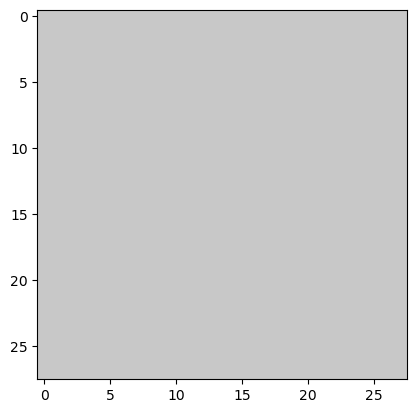

In [221]:
import matplotlib.pyplot as plt
img = np.full((28,28),255,dtype=np.uint8) #=하얀색
img = np.full((28,28),200,dtype=np.uint8) #=회색
#plt.figure(figsize=(1,1))
plt.imshow(img, cmap='gray', vmin=0,vmax=255)
# plt.axis('off')
plt.show()

In [223]:
import numpy as np
np.empty((3,2))

array([[0.37472222, 0.33722222],
       [0.37472222, 4.03322222],
       [4.07072222, 0.33722222]])

## 2.3 랜덤값을 갖는 배열 만들기
※ n차원 배열만들기
- np.random.random(tup) : 0부터 1미만의 균등 분포를 갖는 tup사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0,scale=1.0,size=tup) : 평균loc,표준편차scale을 갖는 정규분포 랜덤값
---
※차원 배열만들기
- np.random.rand(n) : 균등분포의 1차원 난수 배열 발생(난수가 n개)
- np.random.randa(n) : 표준 정규 분포(평균이 0이고 표준편차가1인 정규분포)의 1차원 난수배열발생(난수n개)
---
※ 난수 1개 만들기
- np.rendom.randint(n) 0부터 n미만의 정수 난수 1개 발생==random.randint(0,n-1)
- np.random.randint(from,to) : from부터 새 미만의 정수 난수 1개 발생
                    ==random.randint(from,to)

In [224]:
np.random.random((2,3))

array([[0.81177852, 0.48090204, 0.74776089],
       [0.46574553, 0.91653708, 0.98729967]])

In [226]:
np.random.rand((2))

array([0.90649701, 0.67603113])

In [227]:
np.random.rand(100000)

array([0.56960574, 0.26469163, 0.95605281, ..., 0.69926406, 0.64897171,
       0.39912261])

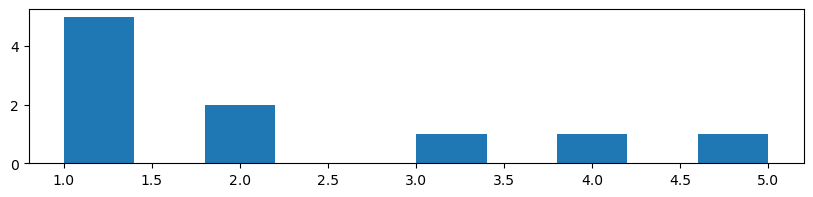

In [242]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
x= [1,2,3,1,2,1,1,4,5,1]
plt.hist(x,bins=10)
plt.show()

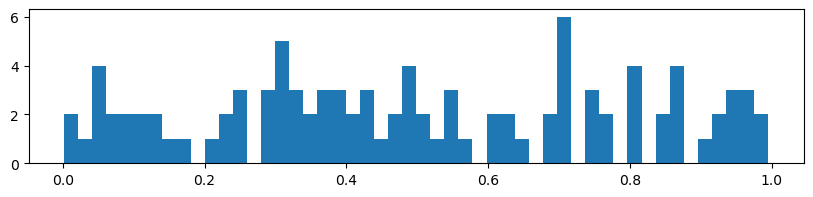

In [244]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
# x= np.random.random(100)
x=np.random.rand(100)
plt.hist(x,bins=50)
plt.show()

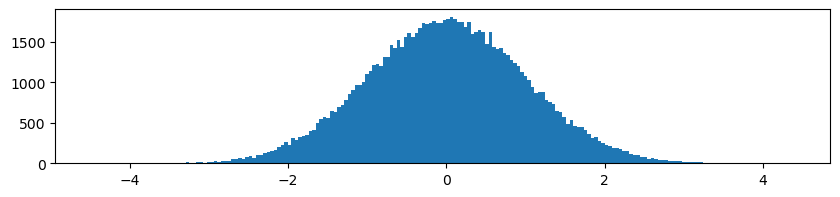

In [254]:
plt.figure(figsize=(10,2)) # 그래프 사이즈 조절
x=np.random.normal(50,10, 1000000) #정규분포
x=np.random.normal(0,1, 1000000) #표준정규분포
x=np.random.randn(100000)
plt.hist(x,bins=200)
plt.show()

In [3]:
# 2차원 균등분포 난수(0~1미만 실수 난수)배열
import numpy as np
#np.random.seed(3) seed값을 맞추면 발생되는 난수가 동일.seed값을 초기화 하려면 커널 재시작
np.random.random((2,5))# 2행 5열짜리 2차원 난수 배열

array([[0.02987621, 0.45683322, 0.64914405, 0.27848728, 0.6762549 ],
       [0.59086282, 0.02398188, 0.55885409, 0.25925245, 0.4151012 ]])

In [4]:
# 2차원 균등분포 난수(-1~1미만 실수 난수)배열
np.random.uniform(-1,1,(2,5)) #2행 5열 짜리 배열

array([[-0.43294984,  0.38627584, -0.11909256, -0.68626452,  0.08929804],
       [ 0.56062953, -0.38727294, -0.55608423, -0.22405748,  0.8727673 ]])

In [6]:
# 2차원 정규분포 난수(평균과 표준편차로 생성된 난수)배열
np.random.normal(3,1,(3,5)) #1행 5열 2차원 배열

array([[4.12397796, 2.86808577, 1.37671455, 3.64667545, 2.64372924],
       [1.25685896, 2.40335036, 2.41140562, 2.1261177 , 3.02971382],
       [0.75174223, 2.73223814, 4.01318344, 3.85279784, 4.1081875 ]])

In [8]:
# 1차원 균등분포 난수 배열
np.random.rand(3)
np.random.random(3)

array([0.06152893, 0.24267542, 0.97160261])

In [10]:
# 1차원 표준정규분포 (평균 0, 표준편차 1인정규분포 )배열
np.random.randn(3)
np.random.normal(size=3)

array([-0.63354599, -0.43551628, -0.37657614])

## 2.4 연속된 값을 갖는 배열 만들기
- np.arange(from,to,by,dtype) : from부터 to(to미포함)앞까지 by씩 건너뛴 값을 1차원 배열로 생성
- linspace(from,to,num) : from부터 to(to포함)까지 num개 숫자들을 1차원 배열로 생성

In [11]:
np.arange(10,30,5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [13]:
np.arange(0,3,0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7])

In [14]:
np.linspace(0,3,20) #0부터 3까지 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [19]:
np.linspace(0,3,20)

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [21]:
x=np.array([0,1,2,3,4,5,6])
x=np.linspace(0,6,200)
y=np.sin(x) 

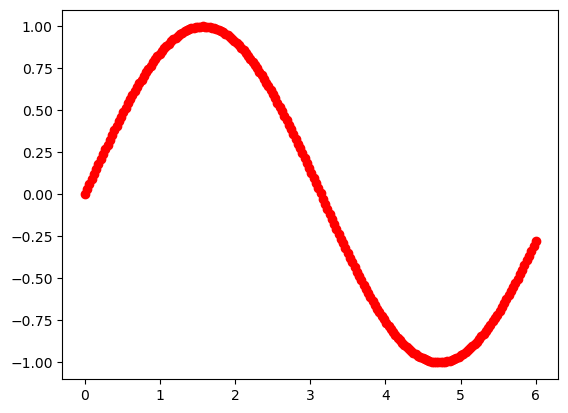

In [22]:
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
plt.scatter(x,y,c='r')# 빨간색 점그래프
#plt.plot(x,y)#선그래프
plt.show()

## 2.5 배열의 차원 변경
- reshape(행수,열수) : - 차원 변경된 배열return(-1가능) 
- resize((행수,열수)) : 배열을 차원변경(-1 불가)
- ravel(),flatten() : 1차원으로 변경된 배열return
- T : 전치행렬로 변환
- transpose() : 전치행렬로 변환

※ 실행결과가 출력되면 배열이 수정되지 않고, 실행결과가 없으면 배열이 수정됨

In [23]:
t=np.random.random((2,5)) 
t

array([[0.10010434, 0.12929386, 0.55327773, 0.18781482, 0.95210124],
       [0.68161178, 0.54101967, 0.7071806 , 0.26388667, 0.92672568]])

In [26]:
# t*10 요소별 연산
# round(t*10) 스칼라 값을 반올림
a=np.round(t*10)
a


array([[ 1.,  1.,  6.,  2., 10.],
       [ 7.,  5.,  7.,  3.,  9.]])

In [28]:
a=a.astype(np.int16)# astype()을 이용한 요소별 타입 변환
a #2행 5열

array([[ 1,  1,  6,  2, 10],
       [ 7,  5,  7,  3,  9]], dtype=int16)

In [29]:
a.reshape(5,2)

array([[ 1,  1],
       [ 6,  2],
       [10,  7],
       [ 5,  7],
       [ 3,  9]], dtype=int16)

In [30]:
a

array([[ 1,  1,  6,  2, 10],
       [ 7,  5,  7,  3,  9]], dtype=int16)

In [31]:
a.reshape(5,-1)# -1이 주어지면 해당 차원의 크기가 자동계산 a의 item이 10이 5행으로 하면 2열로 자동계산

array([[ 1,  1],
       [ 6,  2],
       [10,  7],
       [ 5,  7],
       [ 3,  9]], dtype=int16)

In [32]:
a.reshape(-1,2)

array([[ 1,  1],
       [ 6,  2],
       [10,  7],
       [ 5,  7],
       [ 3,  9]], dtype=int16)

In [34]:
a.resize((2,5))#a를 바꿈
a.resize(2,5)
a

array([[ 1,  1,  6,  2, 10],
       [ 7,  5,  7,  3,  9]], dtype=int16)

In [37]:
a.flatten()

array([ 1,  1,  6,  2, 10,  7,  5,  7,  3,  9], dtype=int16)

In [38]:
a

array([[ 1,  1,  6,  2, 10],
       [ 7,  5,  7,  3,  9]], dtype=int16)

In [40]:
a.T#a의 전치행렬(행과 열을 뒤바꾼 행렬 ex.0행1열->1행 0열)

array([[ 1,  7],
       [ 1,  5],
       [ 6,  7],
       [ 2,  3],
       [10,  9]], dtype=int16)

In [41]:
a.transpose()#a의 전치행렬

array([[ 1,  7],
       [ 1,  5],
       [ 6,  7],
       [ 2,  3],
       [10,  9]], dtype=int16)

## 2.6 배열 인쇄

In [45]:
print(np.arange(1001))# item 갯수가 1000까지만 나와

[   0    1    2 ...  998  999 1000]


In [47]:
np.get_printoptions()['threshold']#출력되는 limit

1000

In [53]:
# 배열이 너무 커서 인쇄할 수없는 경우 자동으로 건너뛰고 모서리 부분만 출력
# 넘파이의 인쇄 옵션변경(인쇄할 사이즈 조정)
np.set_printoptions(threshold=10000) # 배열 10000개까지 출력하도록 옵션 셋팅
np.set_printoptions(threshold=np.inf) #np.inf : 무한대
import sys
np.set_printoptions(threshold=sys.maxsize)

In [54]:
sys.maxsize

9223372036854775807

In [56]:
#커널을 재시작하거나
import numpy as np
np.set_printoptions
np.arange(10000).reshape(100,100)

array([[   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
          11,   12,   13,   14,   15,   16,   17,   18,   19,   20,   21,
          22,   23,   24,   25,   26,   27,   28,   29,   30,   31,   32,
          33,   34,   35,   36,   37,   38,   39,   40,   41,   42,   43,
          44,   45,   46,   47,   48,   49,   50,   51,   52,   53,   54,
          55,   56,   57,   58,   59,   60,   61,   62,   63,   64,   65,
          66,   67,   68,   69,   70,   71,   72,   73,   74,   75,   76,
          77,   78,   79,   80,   81,   82,   83,   84,   85,   86,   87,
          88,   89,   90,   91,   92,   93,   94,   95,   96,   97,   98,
          99],
       [ 100,  101,  102,  103,  104,  105,  106,  107,  108,  109,  110,
         111,  112,  113,  114,  115,  116,  117,  118,  119,  120,  121,
         122,  123,  124,  125,  126,  127,  128,  129,  130,  131,  132,
         133,  134,  135,  136,  137,  138,  139,  140,  141,  142,  143,
         144,  145,  14

## 2.7 기본 연산 동작
### 1)배열의 요소별 연산

In [57]:
a = np.array([10,20,30,40],dtype=np.int8)
b = np.arange(4)# np.int32
print(a) # 배열을 print에 넣으면 array와 ,(콤마)가 안 나옴
print(b)

[10 20 30 40]
[0 1 2 3]


In [61]:
c = a+b #요소별 +연산(dtype은 큰거로,정수와 실수 연산은 실수로)
print(c)
print(c.dtype)

[10 21 32 43]
int32


In [63]:
a*2

array([20, 40, 60, 80], dtype=int8)

In [64]:
a * b #요소별 연산시 dtype이 큰쪽인 int32

array([  0,  20,  60, 120])

In [65]:
a**b

array([    1,    20,   900, 64000], dtype=int32)

In [66]:
a<40

array([ True,  True,  True, False])

In [71]:
print(a[[0,1,2,3]])#index를 list로
print(a[[True, True, True, False]])#booleam index
print(a[[0,2]])

[10 20 30 40]
[10 20 30]
[10 30]


In [72]:
# a배열에서 40 미만인 데이터만 추출하려면 boolean index사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [73]:
# a배열에서 40 미만인 데이터의 index
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2)행렬의 곱(@,dot함수)cf.*(요소별 곱)
- 2차원 배열은 행렬로 취급
-pdf 18page

In [75]:
A=np.array([[1,1],
           [0,1]])
B=np.array([[2,0],
           [3,4]])
A,B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [77]:
print('요소별 곱 A*B=',A*B,sep="\n")
print('행렬 곱 A@B=',A@B,sep="\n")
print('행렬곱 A.dot(B)=',A.dot(B),sep="\n")

요소별 곱 A*B=
[[2 0]
 [0 4]]
행렬 곱 A@B=
[[5 4]
 [3 4]]
행렬곱 A.dot(B)=
[[5 4]
 [3 4]]


In [79]:
#pdf 19
# 1.
a = np.array([[1,2],
             [3,4]])
b = np.array([[-1,-1],
             [1,1]])
print(a@b,b@a,sep="\n")

[[1 1]
 [1 1]]
[[-4 -6]
 [ 4  6]]


In [81]:
a = np.array([[1,2],
             [3,4]])
b = np.array([[6],
              [7],
             ])
print(a@b,sep="\n")
#m행 r열,@ r행 n열 = ? m행 n열
# b@a 에러 <=2x1 @ 2x2

[[20]
 [46]]


In [85]:
a = np.array([[1,2,3],
             [3,4,1]])
b = np.array([[0,0],
              [1,1],
             [-1,2]])
print(a@b)#2x3@3x2=>2x2
print(b@a) # 3x2@2x3 =>3x3

[[-1  8]
 [ 3  6]]
[[ 0  0  0]
 [ 4  6  4]
 [ 5  6 -1]]


In [86]:
# a@b != b@a
# a@단위행렬 == 단위행렬@a ; 단위행렬에서는 행렬곱의 교환법칙이 성립
# 단위 행렬은 정방행렬
A=np.array([[1,0],
           [0,1]]) #2행2열짜리 단위 행렬
B=np.array([[2,0],
           [3,4]]) 
print('a@b=',A@B,sep='\n')

a@b=
[[2 0]
 [3 4]]


In [87]:
print('b@a=',B@A,sep='\n')

b@a=
[[2 0]
 [3 4]]


In [88]:
# 2행 2열 단위 행렬
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 3)복합 대입 연산자 사용(+=,-=,...)
- 배열에서는 a+=b 는 a=a+b와 다소 다르게 작동

In [103]:
a = np.ones((2,3),dtype='int8') # int8범위 -128~127
b = np.random.random((2,3)) # float64
print(a,b,sep='\t')

[[1 1 1]
 [1 1 1]]	[[0.91397527 0.63366556 0.36594058]
 [0.55284457 0.19638058 0.1920723 ]]


In [105]:
a[0,0]=128 #공간이 부족하면 a에 오류
a

array([[-128,    1,    1],
       [   1,    1,    1]], dtype=int8)

In [107]:
a +=127 # a+255

In [108]:
b+=5 # a=a+5
b

array([[10.91397527, 10.63366556, 10.36594058],
       [10.55284457, 10.19638058, 10.1920723 ]])

In [94]:
a+=b # a+b(float64)를 기존의 a에 넣는다.
a

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int8') with casting rule 'same_kind'

In [95]:
# 스칼라 데이터 에서는 문제되지 않음
x = 5
y = 5.7
x+=y
x

10.7

### 4)배열 요소별 집계
- sum,min,max,mean,var(분산),std(표준편차)

In [110]:
a = np.array([[2,2,2,3],
             [4,3,2,1]])

In [111]:
print('전체 합=',a.sum(),np.sum(a))
print('전체 최소값=',a.min(),np.min(a))
print('전체 최대값=',a.max(),np.max(a))
print('전체 평균=',a.mean(),np.mean(a))
print('전체 분산=',a.var(),np.var(a))
print('전체 표준편차=',a.std(),np.std(a))

전체 합= 19 19
전체 최소값= 1 1
전체 최대값= 4 4
전체 평균= 2.375 2.375
전체 분산= 0.734375 0.734375
전체 표준편차= 0.8569568250501305 0.8569568250501305


In [112]:
# 분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var())#math.sqrt(스칼라값)

0.8569568250501305

### 5) 배열 축별 집계(2차원일때 axis0=열,axis1=행)
- 축별 sum,min,max,mean,var,std
    * (1차원일때 axis0=열
    * (2차원일때 axis0=행 , axis1=열)
    * (3차원일때 axis0=면 , axis1=행, axis2=열)

In [113]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [116]:
# axis=1(1측)들의 합 : 행을 고정하고 1축(열들)의 합
print('a의 행별합:',a.sum(axis=1),np.sum(a,axis=1))

a의 행별합: [ 9 10] [ 9 10]


In [120]:
# axis=1을 고정하고 0축(행들)의 합
print('a의 열별합:',a.sum(axis=0),np.sum(a,axis=0))

a의 열별합: [6 5 4 4] [6 5 4 4]


In [121]:
# 3차원 배열의 집계
b=np.arange(24).reshape(2,3,4) #2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [123]:
b[0,1,2]

6

In [ ]:
b.sum(),np.sum(b),b.min()np.min(b) #배열 전체 요소에 대한 집계

In [124]:
b.sum(axis=0) #행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [125]:
b.sum(axis=1) # 면과 열은 고정하고 행이 합0,0,0+0,1,0+0,0,2

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [126]:
b.sum(axis=2) #면과 행은 고정히고 열들의 합

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근
- np.add(A,B,C) : c=np.add(A,B)와 동일 / C=A+B와 동일 의미
- np.multiply(A,B,C) : C=np.multiply(A,B) / C=A+B와 동일 의미
- np.subtract(A,B,C) : C=np.subtract(A,B) / C=A-B와 동일 의미

In [127]:
a = np.array([1,4])
b = np.array([3,4])
c = np.empty(2)
a,b,c

(array([1, 4]), array([3, 4]), array([1.06099790e-313, 8.48798317e-314]))

In [130]:
#math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [132]:
np.add(a,b,c) # c=np.add(a,b),c=a+b
c=a+b
c

array([4., 8.])

## 2.9 브로드 케스팅
- 서로 다른 크기의 배열 간 연산을 수행

In [134]:
# 1차원 배열인 경우(pdf 26p.)
a = np.array([1,2,3])
b = np.array([2])
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [137]:
a = np.array([1,2,3])
b = 2
print(a+b)
print(np.add(a,b))

[3 4 5]
[3 4 5]


In [138]:
a*b

array([2, 4, 6])

In [142]:
# 2차원 배열인 경우의 브로드 캐스팅
a = np.array([[0,0,0],
            [10,10,10],
            [20,20,20],
            [30,30,30]]) #4x3배열
b = np.array([[0],
            [1],
            [2],
            [3]]) # 4x1열짜리 배열
a + b
# 브로드 캐스팅되서 아래와 같이 연산
# b = np.array([[0,0,0],
#             [1,1,1],
#             [2,2,2],
#             [3,3,3]]) # 4x1열짜리 배열

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [143]:
# 브로드 캐스팅을 할 수 없는 예(pdf 28p.)
a=np.array([0,10,20,30])
b=np.array([1,2,3])
a+b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [145]:
a

array([ 0, 10, 20, 30])

In [157]:
#np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가=>2차원
A = a[:,np.newaxis]
# A = a.reshape(-1,1)
# A = np.expand_dims(a,axis=1)
A
# np.array([[0],
#         [10],
#         [20],
#         [30]])

array([[ 0],
       [10],
       [20],
       [30]])

In [158]:
# a와 b의 모든 쌍 조합에 계산하고 싶을때 브로드 캐스팅 특성 이용
A+b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [159]:
ax, bx = np.ix_(a,b) #n개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절. 배열 합치기와 배열 분리하기
-[numpy_API_Docs] (https://numpy.org/doc/stable/reference/index.html)
- 슬라이싱
- 두배열을 합치는 함수
- r_,c_
- 하나의 배열을 여러개 작은 배열로 분리하는 함수
## 3.1 다차원 배열 인덱싱과 슬라이싱

In [161]:
b = np.arange(20).reshape(5,4) 
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [162]:
b[2,1]#없는 인덱싱시 에러

9

In [163]:
# 모든행의 마지막 열 앞까지(종속변수를 제외하는 용도)모든행의 경우, 선행측은 생략 불가능ex.b[,:-1]
b[:,:-1]
b[...,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [165]:
# 0~2행까지 모든 열 (모든열의 경우, 생략가능==모든 열의 경우,후행축은 생략 가능)
b[0:3,:]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [167]:
b[3:,2:]
b[-2:,-2:]

array([[14, 15],
       [18, 19]])

## 3.2 두배열을 쌓아 합치는 함수
- vstack( tup ) : 아래로 추가하는 방식
- hstack( tup ) : 옆으로 추가하는 방식
- tstack( tup ) : 마지막 축(열)을 쌓아 합침(차원증가)

In [2]:
import numpy as np
c = np.array([1,2,3])
d = np.array([4,5,6])
v = np.vstack((c,d))
print('vstack으로 아래로 합치기:',v,v.shape,sep='\n')
h = np.hstack((c,d))
print('hstack으로 옆으로 합치기:',h,h.shape,sep='\n')
d = np.dstack((c,d)) 
print('dstack으로 depth로 합치기:',d,d.shape,sep='\n')

vstack으로 아래로 합치기:
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기:
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기:
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [3]:
c = np.arange(24).reshape(2,3,4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [4]:
a,b=c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [5]:
# 수직으로 합치기
np.vstack((a,b))

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [6]:
np.concatenate((a,b),axis=0) #axis=0이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [7]:
#수평으로 합치기
np.hstack((a,b))

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [9]:
np.concatenate((a,b),axis=1)

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [10]:
np.dstack((a,b))


array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

- column_stack(tup):1차원 배열을 2차우너 배열의 열단위 합침
- row_stack(tup) :행단위로 합침 == cstack()


In [11]:
a = np.array([1,2,3,4])
b = np.array([5,6,7,8])
c = np.array([9,10,11,12])
np.column_stack((a,b,c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [186]:
np.hstack((a[:,np.newaxis],b[:,np.newaxis],c[:,np.newaxis]))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

- stack(tup,axis=n) : axis속성에 따라 배열을 합침. axis은 음수차원 0첫번째 

In [21]:
c = np.arange(24).reshape(2,3,4)
a,b=c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [22]:
np.stack((a,b),axis=0)#2차원 배열끼리 stack하면 3차원으로 axis=0면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [23]:
np.stack((a,b),axis=1)

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [24]:
np.stack((a,b),axis=2)

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

In [12]:
np.row_stack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [14]:
np.row_stack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [16]:
np.vstack((a,b,c))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [19]:
np.stack((a,b),axis=0)

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

## 3.3 r_,c_
- 나열 객체

In [194]:
a = np.array([1,2,3,4])
b = np.array([5,6,7,8])
c = np.array([9,10,11,12])

In [195]:
np.r_[a,b,c]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [196]:
np.r_[[a],[b],[c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [198]:
np.c_[a,b,c] #컬럼 단위로 쌓아줌(c_와 column_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [199]:
np.column_stack((a,b,c))

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수
- vsplit(ary,정수나 백터) : 첫번째 축(axis0-2차원의 경우 가로축)을 따라 분할 
- hsplit(ary,정수나 백터) : 두번째 축(axis1-2차원의 경우 세로축)을 따라 분할
- split(ary,정수나 백터,axis)
---
- array_split(ary,정수나 백터,axis) 
- **split()과 차이점은 나눠지지않은 정수로도 사용가능**

In [202]:
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [203]:
a_split = np.vsplit(a,3) # 가로축(axis0축)을따라 3개로 분할
a_split

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [205]:
a_split = np.vsplit(a,[2]) # 가로축(axis0축)을따라 1번쨰 index,2번째 index앞에서 분할
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [206]:
np.hsplit(a,2) #a를 2개로 새로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [207]:
np.hsplit(a,[3])#a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [209]:
np.split(a,3,axis=0) # 0측으로 분리. 2차원에서의 vsplit(a,3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [210]:
np.split(a,2,axis=1) # 1축으로 분리. 2차원에서 

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [211]:
# np.split(a,3,axis=1)
np.array_split(a,3,axis=1) #나눠지지않는 정수 개수를 알아서 나눠

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [213]:
np.split(a,[1,2],axis=1) #1번째 index,2번째 

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4절. 복사와 뷰
## 4.1 할당

In [146]:
# 스칼라 변수
a=10
b=a
print('a와 b주소 : ',id(a),id(b))
b=99
print('수정 후 a와 b주소:',id(a),id(b))
print('수정 후 a와 b데이타:' ,a, b)

a와 b주소 :  2018177581584 2018177581584
수정 후 a와 b주소: 2018177581584 2018177584432
수정 후 a와 b데이타: 10 99


In [147]:
# 배열
a=np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [149]:
b=a
# b=np.array(a,copy=False)와 같음
a.shape,type(a),a.ndim,id(a)

((12,), numpy.ndarray, 1, 2018318418640)

In [150]:
a is b

True

In [151]:
a==b

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [152]:
np.all(a==b) # np.all()array배열안의 모든 값이 True인지 여부

True

In [153]:
b.shape = (3,4)

In [154]:
b.shape, type(b),b.ndim,id(b)

((3, 4), numpy.ndarray, 2, 2018318418640)

In [155]:
a is b

True

In [156]:
a.shape

(3, 4)

In [157]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2 뷰(view): 얕은 복사

In [159]:
a= np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [160]:
c = a.view() #얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [161]:
id(a),id(c)

(2018318477200, 2018328744016)

In [164]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [165]:
np.all(a==c)

True

In [167]:
a is c

False

In [171]:
c.shape = (2,6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [172]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [175]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2]=-99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [176]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [197]:
# 슬라이싱이 될때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a=np.array([[99, 88, 77, 85],
          [99, 71, 75, 70],
          [99, 95, 90, 95],])
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

In [194]:
X = a[:,:-1].copy()
X

array([[99, 88, 77],
       [99, 71, 75],
       [99, 95, 90]])

In [195]:
X[0:2, -1] =1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [99, 71,  1],
       [99, 95, -1]])

In [196]:
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

## 4.3 깊은 복사

In [198]:
# 슬라이싱이 될때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a=np.array([[99, 88, 77, 85],
          [99, 71, 75, 70],
          [99, 95, 90, 95],])
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

In [ ]:
#X=a[:,:-1] #얕은 복사(view생성)
X=a[:,:-1].copy() #깊은 복사
#X= np.array(a[:,:-1],copy=True) # 깊은복사

In [199]:
X[:,0:2] = 1
X[-1,-1] =-1
X

array([[ 1,  1,  1],
       [ 1,  1,  1],
       [ 1,  1, -1]])

In [200]:
a

array([[99, 88, 77, 85],
       [99, 71, 75, 70],
       [99, 95, 90, 95]])

# 5절. 고급인덱싱
## 5.1 인덱스 배열로 인덱싱

In [214]:
a = np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [216]:
a[[0,5,9]]

array([ 0, 25, 81])

In [217]:
a[[0,1,1,5]]

array([ 0,  1,  1, 25])

In [218]:
# 인덱싱하기 위한 값을 1차원 배열
idx_ary = np.array([0,5,5,8])
a[idx_ary] #결과는 인덱싱 배열(4열짜리 1차원배열)의 형태로 따라감

array([ 0, 25, 25, 64])

In [221]:
# 인덱싱하기 위한 값을 2차원 배열
idx_ary = np.array([[0, 5],
                  [5, 8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [222]:
# 인덱스 배열을 이용한 a수정
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [223]:
a[idx_ary]+=9 #0번째, 5번째, 8번째, 복합 대입연산자가 5번째는 한번만
a

array([  0,   1,   4,   9,  16,   0,  36,  49,   0,  81, 100, 121])

## 5.2 argmax : 최대값이 있는 인덱스

In [225]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [226]:
# 각 열별 큰 값이 있는 index 행수
ind=data.argmax(axis=0) # 0행 1행,2행,3행중 가장 큰 값이 잇는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [227]:
# 0열에서 제일 큰 행값, 1열에서 제일 큰 행값
data[ind[0],0], data[ind[1],1]

(0.9893582466233818, 0.8414709848078965)

In [228]:
data_col_max = data[ind,range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [230]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [231]:
# 두 배열이 같은지 여부
np.all(data_col_max == data.max(axis=0))

True

## 5.3 논리 배열을 이용한 인덱싱
- boolean index

In [232]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [234]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [235]:
a[a%2==0]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [236]:
a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [237]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6절 선형 대수
- 2차원 배열을 행렬
    * 행렬곱 : @,np.dot()
    * 역행렬 : 어떤행렬과 역행렬을 행렬곱하면 결과가 단위 행렬 np.linalg.inv(x)
    * 전치행렬 : X.T,X.trenspose()
    * 단위행렬 : np.eye(n) n행n열

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F444IE%2FbtqYKaRk1gS%2FAAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DyVKMv7SY28sGjG4YykrL3KzDzYM%253D"
     width="400"
     style="float:left">